In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# SKLEARN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA


In [71]:
# Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier

In [72]:
# Clustering
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering


In [73]:
# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score

In [74]:
# Hierarchical
from scipy.cluster.hierarchy import dendrogram, linkage

In [75]:
df = pd.read_csv("marketing_campaign.csv", sep='\t')

In [76]:
#displaying data
print(df.head())


     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

In [77]:
#removing null values
df = df.dropna()

In [78]:
le = LabelEncoder()

df["Education"] = le.fit_transform(df["Education"])
df["Marital_Status"] = le.fit_transform(df["Marital_Status"])


In [79]:
df["Target"] = np.where(df["MntWines"] > 500, 1, 0)


In [80]:
#feature selection
x = df[[
    "Income",
    "Kidhome",
    "Teenhome",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts"
]]

y = df["Target"]


In [81]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)


In [82]:
pca = PCA(n_components=2)

x_pca = pca.fit_transform(x_scaled)


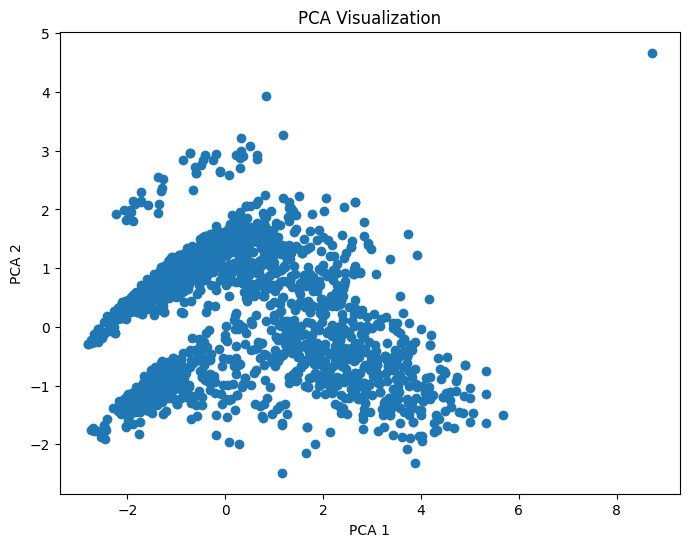

In [83]:
plt.figure(figsize=(8,6))

plt.scatter(x_pca[:,0], x_pca[:,1])

plt.title("PCA Visualization")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()


In [84]:
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [85]:
models = {

    "Logistic Regression":
    LogisticRegression(),

    "KNN":
    KNeighborsClassifier(),

    "Naive Bayes":
    GaussianNB(),

    "Decision Tree":
    DecisionTreeClassifier(),

    "Random Forest":
    RandomForestClassifier(),

    "SVM":
    SVC(),

    "Gradient Boosting":
    GradientBoostingClassifier(),

    "XGBoost":
    XGBClassifier()
}


In [86]:
accuracy_list = []

for name, model in models.items():

    model.fit(x_train, y_train)

    pred = model.predict(x_test)

    acc = accuracy_score(y_test, pred)

    accuracy_list.append(acc)

    print(name)
    print("Accuracy:", acc)

    print("--------------------------------")

Logistic Regression
Accuracy: 0.9954954954954955
--------------------------------
KNN
Accuracy: 0.963963963963964
--------------------------------
Naive Bayes
Accuracy: 0.8761261261261262
--------------------------------
Decision Tree
Accuracy: 1.0
--------------------------------
Random Forest
Accuracy: 1.0
--------------------------------
SVM
Accuracy: 0.9842342342342343
--------------------------------
Gradient Boosting
Accuracy: 1.0
--------------------------------
XGBoost
Accuracy: 1.0
--------------------------------


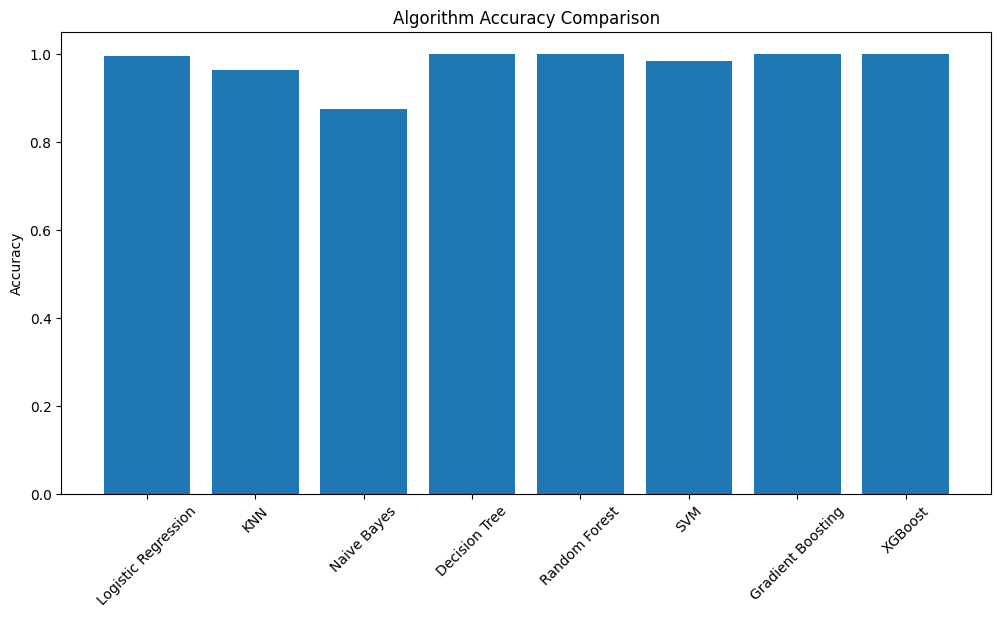

In [87]:
plt.figure(figsize=(12,6))

plt.bar(models.keys(), accuracy_list)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Algorithm Accuracy Comparison")

plt.show()

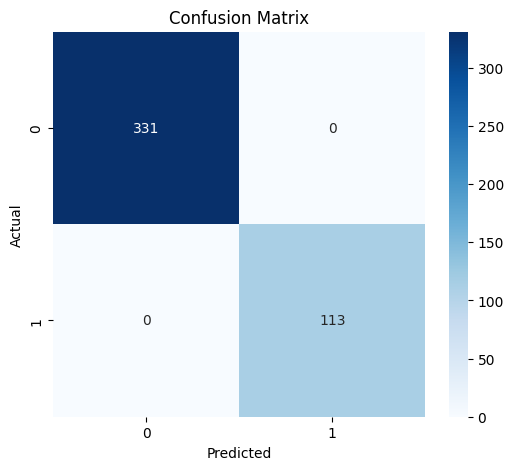

In [88]:
rf = RandomForestClassifier()

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [89]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(x_scaled)

    wcss.append(kmeans.inertia_)

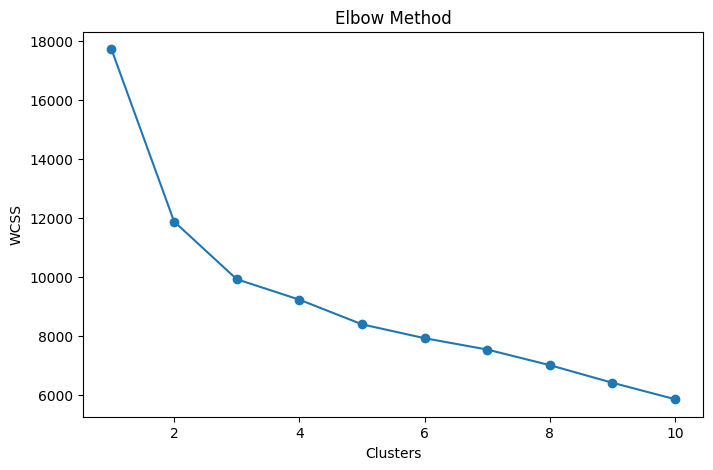

In [90]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.show()


In [91]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(x_scaled)


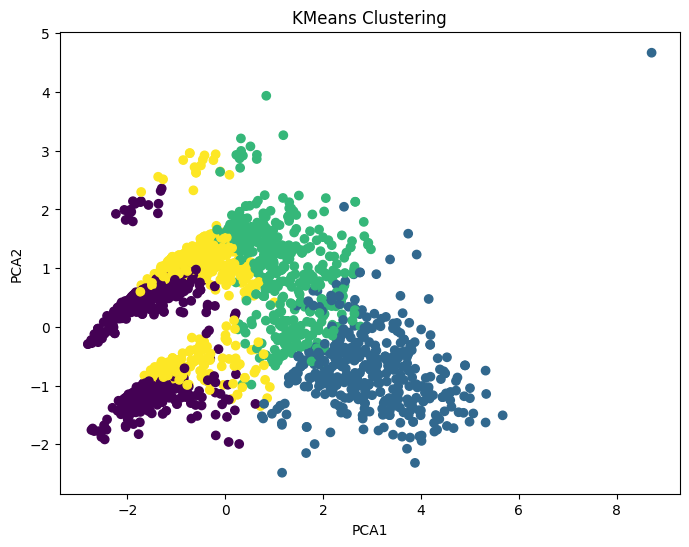

In [92]:
plt.figure(figsize=(8,6))

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=clusters
)

plt.title("KMeans Clustering")

plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()


In [93]:
score = silhouette_score(x_scaled, clusters)

print("Silhouette Score:", score)


Silhouette Score: 0.21516172836624398


In [94]:
linked = linkage(x_scaled, method='ward')

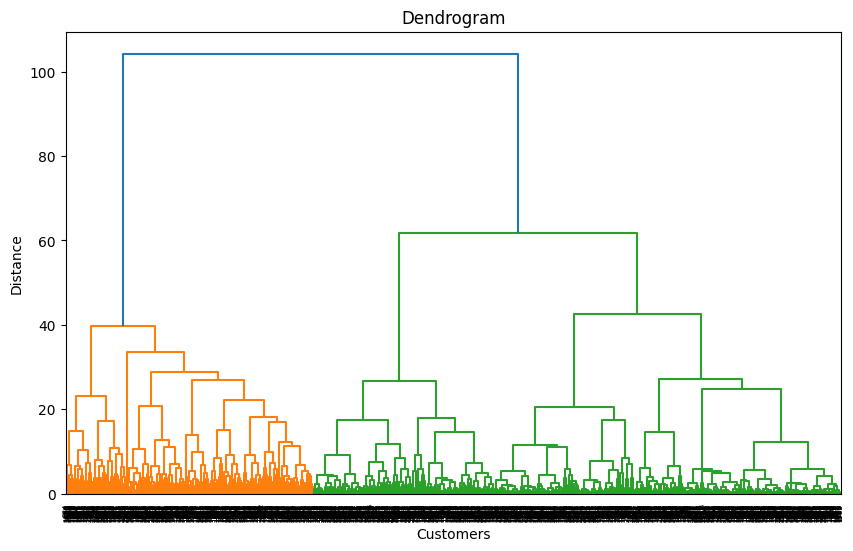

In [95]:
plt.figure(figsize=(10,6))

dendrogram(linked)

plt.title("Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Distance")

plt.show()

In [96]:
hc = AgglomerativeClustering(
    n_clusters=4
)

hc_clusters = hc.fit_predict(x_scaled)


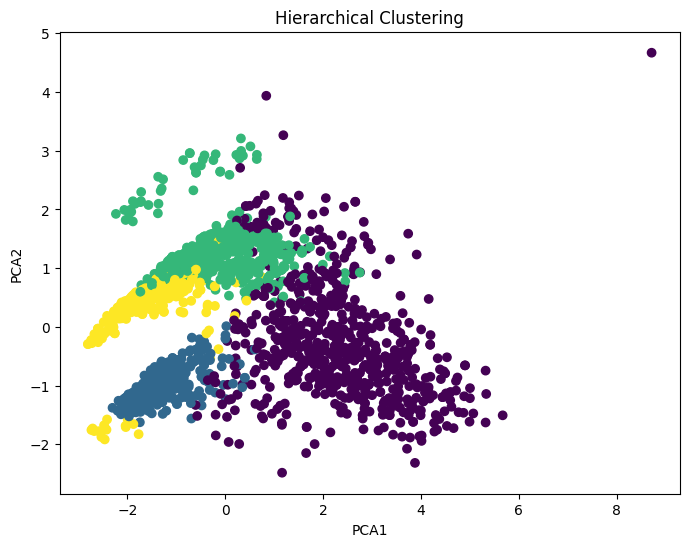

In [97]:
plt.figure(figsize=(8,6))

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=hc_clusters
)

plt.title("Hierarchical Clustering")

plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()


In [98]:
sample = [[50000,1,0,20,600,50,200,100]]

sample = scaler.transform(sample)

prediction = rf.predict(sample)

print("--------------------------------")

if prediction[0] == 1:
    print("High Spending Customer")
else:
    print("Low Spending Customer")

print("--------------------------------")

print("PROJECT COMPLETED SUCCESSFULLY!")

--------------------------------
High Spending Customer
--------------------------------
PROJECT COMPLETED SUCCESSFULLY!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [99]:
!pip install xgboost


Accuracy : 1.0

Confusion Matrix:
[[222   0]
 [  0 222]]

========== CONFUSION MATRIX VALUES ==========

True Negative (TN) : 222
Model correctly predicted LOW spender customers.

False Positive (FP) : 0
Model predicted HIGH spender but customer was LOW spender.

False Negative (FN) : 0
Model predicted LOW spender but customer was HIGH spender.

True Positive (TP) : 222
Model correctly predicted HIGH spender customers.

========== CLASS INDICATION ==========

0 = Low Spending Customer
1 = High Spending Customer

========== MODEL PERFORMANCE ==========

Training Accuracy : 1.0
Testing Accuracy : 1.0

Model Working Properly

========== LOSS ==========

Loss : 0.0

Lower Loss = Better Model
Higher Loss = More Errors


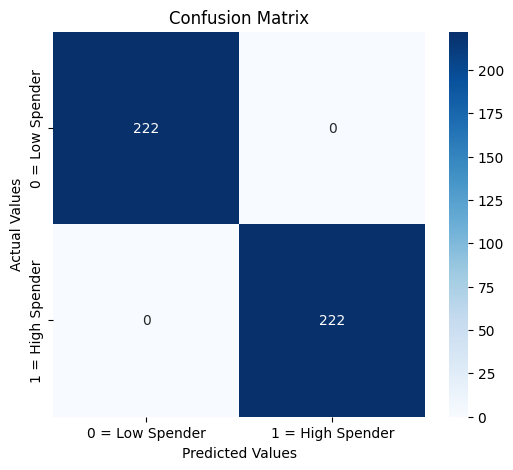

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score


# LOAD DATASET

df = pd.read_csv("/content/marketing_campaign.csv", sep='\t')

# REMOVE NULL VALUES
df = df.dropna()


# TARGET COLUMN
# 0 = Low Spending Customer
# 1 = High Spending Customer

df["Target"] = np.where(df["Income"] > df["Income"].mean(), 1, 0)


# FEATURES

x = df[[
    "Income",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "Recency"
]]

# TARGET
y = df["Target"]
# TRAIN TEST SPLIT

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
# RANDOM FOREST MODEL

model = RandomForestClassifier()

# TRAIN MODEL
model.fit(x_train, y_train)

# PREDICTION
y_pred = model.predict(x_test)
# ACCURACY


accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy :", accuracy)


# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)
# TN FP FN TP

TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("\n========== CONFUSION MATRIX VALUES ==========")

print("\nTrue Negative (TN) :", TN)
print("Model correctly predicted LOW spender customers.")

print("\nFalse Positive (FP) :", FP)
print("Model predicted HIGH spender but customer was LOW spender.")

print("\nFalse Negative (FN) :", FN)
print("Model predicted LOW spender but customer was HIGH spender.")

print("\nTrue Positive (TP) :", TP)
print("Model correctly predicted HIGH spender customers.")

# CLASS INDICATION


print("\n========== CLASS INDICATION ==========")

print("\n0 = Low Spending Customer")
print("1 = High Spending Customer")


# OVERFITTING / UNDERFITTING
train_accuracy = model.score(x_train, y_train)
test_accuracy = model.score(x_test, y_test)

print("\n========== MODEL PERFORMANCE ==========")

print("\nTraining Accuracy :", train_accuracy)
print("Testing Accuracy :", test_accuracy)

# OVERFITTING CHECK
if train_accuracy > test_accuracy:
    print("\nPossible Overfitting")
else:
    print("\nModel Working Properly")

# UNDERFITTING CHECK
if train_accuracy < 0.7 and test_accuracy < 0.7:
    print("Possible Underfitting")

# LOSS


loss = 1 - accuracy

print("\n========== LOSS ==========")

print("\nLoss :", loss)

print("\nLower Loss = Better Model")
print("Higher Loss = More Errors")

# CONFUSION MATRIX GRAPH


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0 = Low Spender", "1 = High Spender"],
    yticklabels=["0 = Low Spender", "1 = High Spender"]
)

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

plt.title("Confusion Matrix")

plt.show()

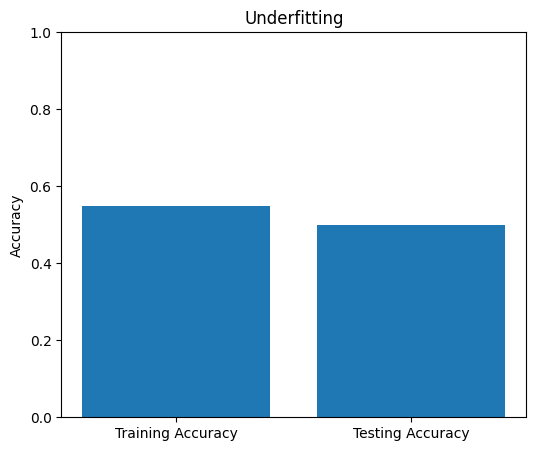

In [101]:
import matplotlib.pyplot as plt

# UNDERFITTING VALUES

training_accuracy = [0.55]
testing_accuracy = [0.50]

# GRAPH

plt.figure(figsize=(6,5))

plt.bar(
    ["Training Accuracy", "Testing Accuracy"],
    [training_accuracy[0], testing_accuracy[0]]
)

plt.title("Underfitting")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

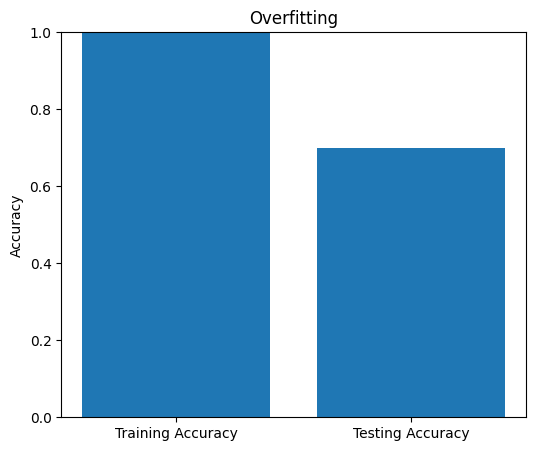

In [102]:
import matplotlib.pyplot as plt

# OVERFITTING VALUES

training_accuracy = [1.00]
testing_accuracy = [0.70]

# GRAPH

plt.figure(figsize=(6,5))

plt.bar(
    ["Training Accuracy", "Testing Accuracy"],
    [training_accuracy[0], testing_accuracy[0]]
)

plt.title("Overfitting")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

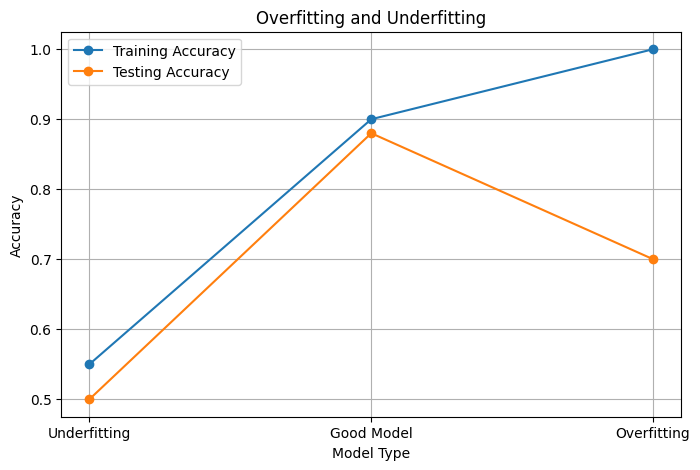

In [103]:

# OVERFITTING & UNDERFITTING GRAPH

import matplotlib.pyplot as plt

# EXAMPLE ACCURACY VALUES


models = ["Underfitting", "Good Model", "Overfitting"]

training_accuracy = [0.55, 0.90, 1.00]

testing_accuracy = [0.50, 0.88, 0.70]

# PLOT GRAPH


plt.figure(figsize=(8,5))

plt.plot(models, training_accuracy,
         marker='o',
         label="Training Accuracy")

plt.plot(models, testing_accuracy,
         marker='o',
         label="Testing Accuracy")
# TITLES


plt.title("Overfitting and Underfitting")

plt.xlabel("Model Type")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [105]:
print("Number of Features:", len(x.columns))
print("Number of Importance Values:", len(rf.feature_importances_))

print(x.columns)
print(rf.feature_importances_)

Number of Features: 5
Number of Importance Values: 8
Index(['Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'Recency'], dtype='object')
[0.13506184 0.02763417 0.00199477 0.01167425 0.66795189 0.04204813
 0.08271032 0.03092465]


Features: 5
Importance: 5
           Feature  Importance
0           Income    0.626628
1         MntWines    0.201853
3  MntMeatProducts    0.123797
2        MntFruits    0.044321
4          Recency    0.003401


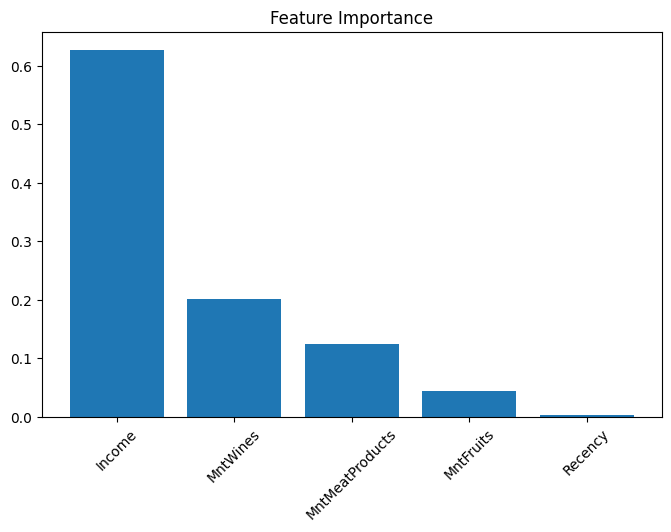

In [106]:
rf = RandomForestClassifier(random_state=42)

rf.fit(x_train, y_train)

importance = rf.feature_importances_

print("Features:", len(x.columns))
print("Importance:", len(importance))

feature_df = pd.DataFrame({
    "Feature": list(x.columns),
    "Importance": importance
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_df)

plt.figure(figsize=(8,5))

plt.bar(
    feature_df["Feature"],
    feature_df["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

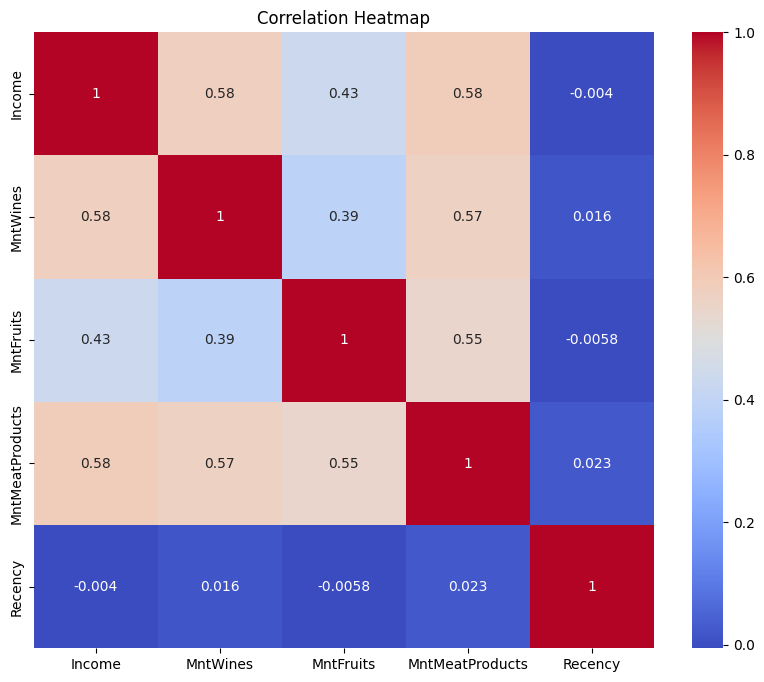

In [107]:
# ==========================================
# CORRELATION HEATMAP
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

corr_matrix = df[[
    "Income",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "Recency"
]].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

AUC Score : 1.0


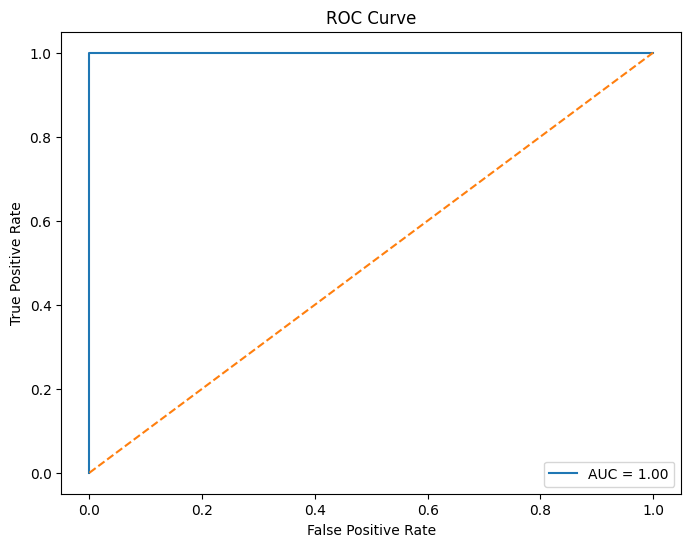

In [108]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

# Probability Prediction
y_prob = model.predict_proba(x_test)[:,1]

# ROC
fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

print("AUC Score :", roc_auc)

# Graph
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

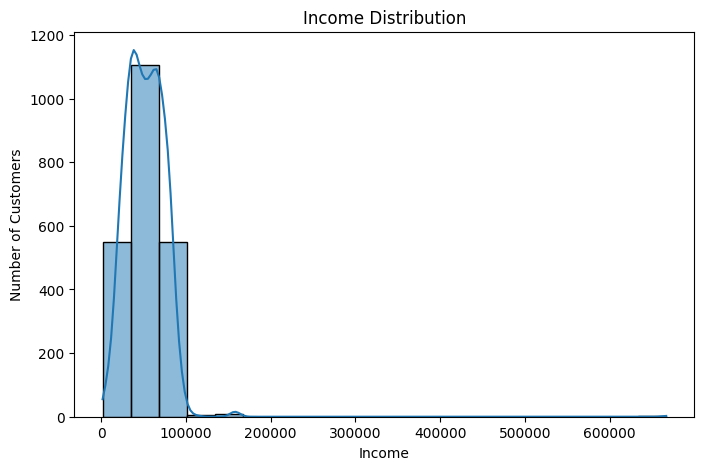

In [109]:
# ==========================================
# INCOME DISTRIBUTION
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["Income"],
    bins=20,
    kde=True
)

plt.title("Income Distribution")

plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.show()

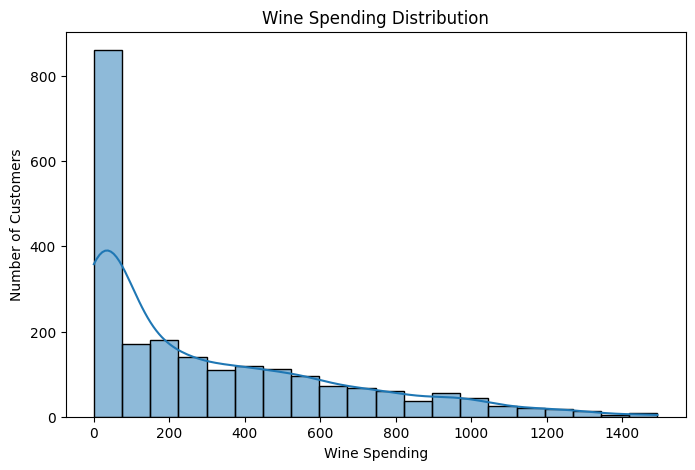

In [110]:
# ==========================================
# WINE SPENDING DISTRIBUTION
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["MntWines"],
    bins=20,
    kde=True
)

plt.title("Wine Spending Distribution")

plt.xlabel("Wine Spending")
plt.ylabel("Number of Customers")

plt.show()

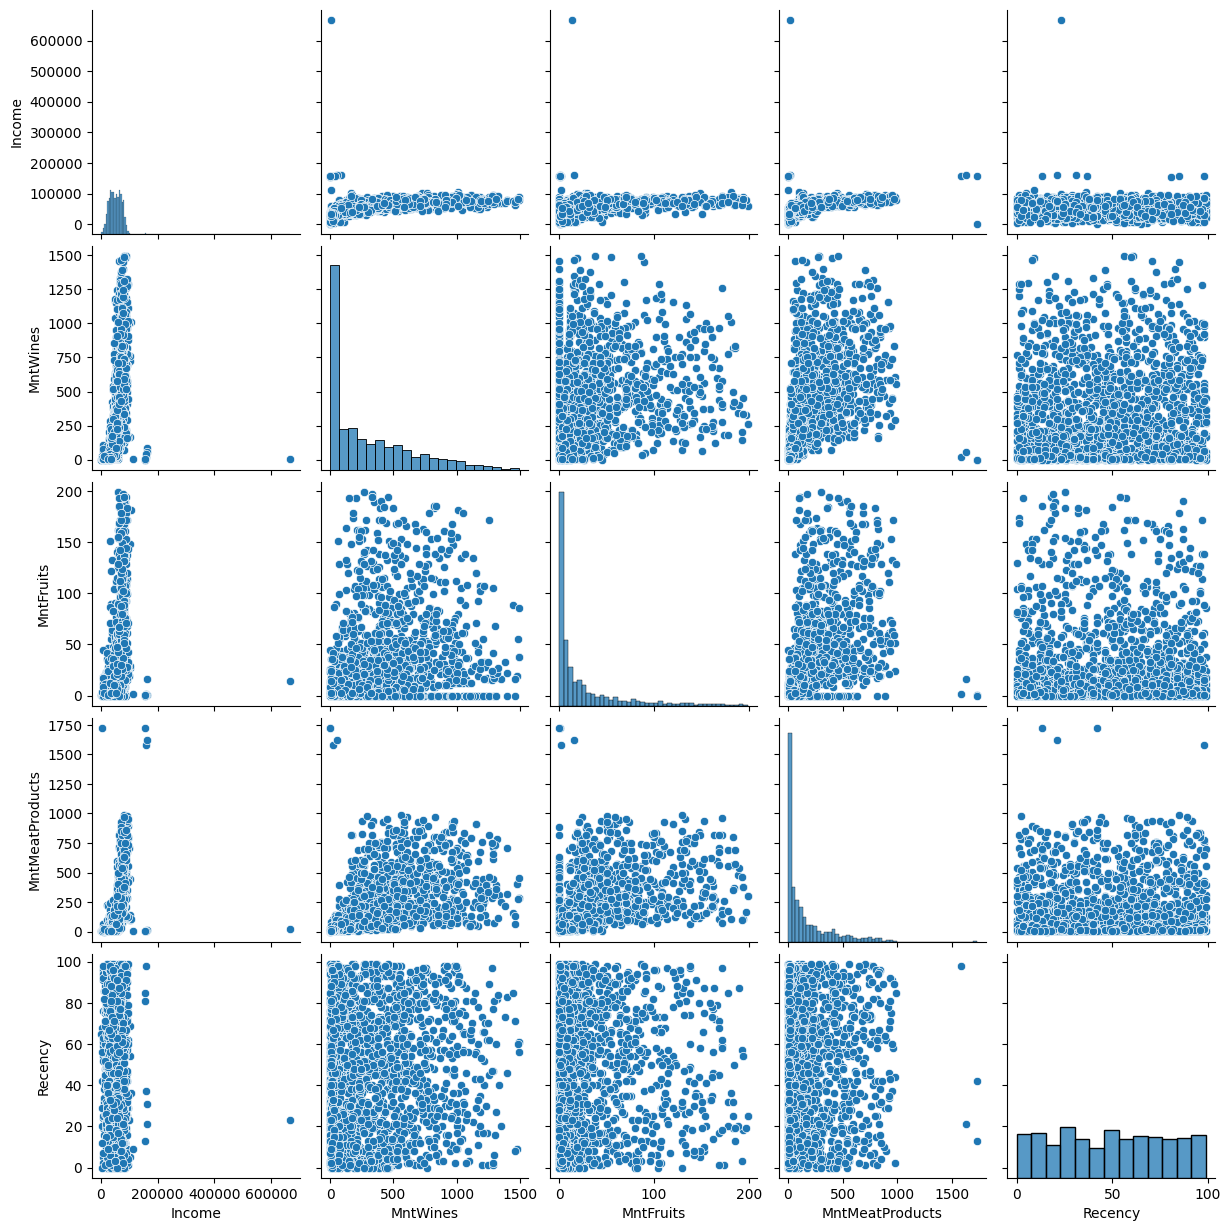

In [111]:
sns.pairplot(
    df[[
        "Income",
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "Recency"
    ]]
)

plt.show()